<a href="https://colab.research.google.com/github/Misbahuddin111/deep-learning/blob/main/7_dropouts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing , load_breast_cancer

import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense , Dropout
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential

In [3]:
# regression example
housing = fetch_california_housing()
X = housing.data
Y = housing.target

In [4]:
# Load California housing
housing = fetch_california_housing()
X_housing, y_housing = housing.data, housing.target

# Train/test split
X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)

# Scale features (important for neural networks)
scaler_h = StandardScaler()
X_h_train = scaler_h.fit_transform(X_h_train)
X_h_test = scaler_h.transform(X_h_test)

print("Housing data shapes:", X_h_train.shape, y_h_train.shape)

Housing data shapes: (16512, 8) (16512,)


In [5]:

def build_regression_model(use_dropout=False, dropout_rate=0.2):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(X_h_train.shape[1],)))
    if use_dropout:
        model.add(Dropout(dropout_rate))
    model.add(Dense(64, activation='relu'))
    if use_dropout:
        model.add(Dropout(dropout_rate))
    model.add(Dense(1))  # linear output

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='mse',
                  metrics=['mae'])
    return model

# Early stopping to avoid overtraining (fair comparison)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [6]:
model_reg_no_drop = build_regression_model(use_dropout=False)
history_no_drop = model_reg_no_drop.fit(
    X_h_train, y_h_train,
    validation_data=(X_h_test, y_h_test),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model_reg_drop = build_regression_model(use_dropout=True, dropout_rate=0.3)
history_drop = model_reg_drop.fit(
    X_h_train, y_h_train,
    validation_data=(X_h_test, y_h_test),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

##****#n3. Classification Example (Breast Cancer)****

### 3. Classification Example (Breast Cancer)

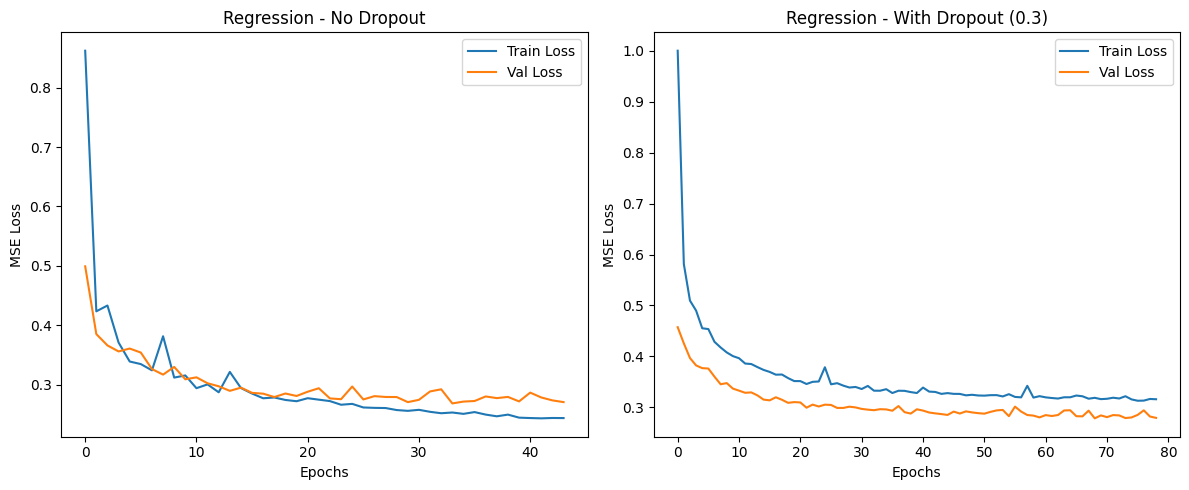

In [8]:
plt.figure(figsize=(12,5))

# Without dropout
plt.subplot(1,2,1)
plt.plot(history_no_drop.history['loss'], label='Train Loss')
plt.plot(history_no_drop.history['val_loss'], label='Val Loss')
plt.title('Regression - No Dropout')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()

# With dropout
plt.subplot(1,2,2)
plt.plot(history_drop.history['loss'], label='Train Loss')
plt.plot(history_drop.history['val_loss'], label='Val Loss')
plt.title('Regression - With Dropout (0.3)')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()

plt.tight_layout()
plt.show()

### 3. Classification Example (Breast Cancer)

In [9]:
# Load breast cancer dataset
cancer = load_breast_cancer()
X_cancer, y_cancer = cancer.data, cancer.target

# Train/test split
X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42, stratify=y_cancer
)

# Scale features
scaler_c = StandardScaler()
X_c_train = scaler_c.fit_transform(X_c_train)
X_c_test = scaler_c.transform(X_c_test)

print("Cancer data shapes:", X_c_train.shape, y_c_train.shape)

Cancer data shapes: (455, 30) (455,)


In [10]:
def build_classification_model(use_dropout=False, dropout_rate=0.2):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(X_c_train.shape[1],)))
    if use_dropout:
        model.add(Dropout(dropout_rate))
    model.add(Dense(64, activation='relu'))
    if use_dropout:
        model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))  # binary output

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [11]:
model_clf_no_drop = build_classification_model(use_dropout=False)
history_clf_no_drop = model_clf_no_drop.fit(
    X_c_train, y_c_train,
    validation_data=(X_c_test, y_c_test),
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model_clf_drop = build_classification_model(use_dropout=True, dropout_rate=0.3)
history_clf_drop = model_clf_drop.fit(
    X_c_train, y_c_train,
    validation_data=(X_c_test, y_c_test),
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

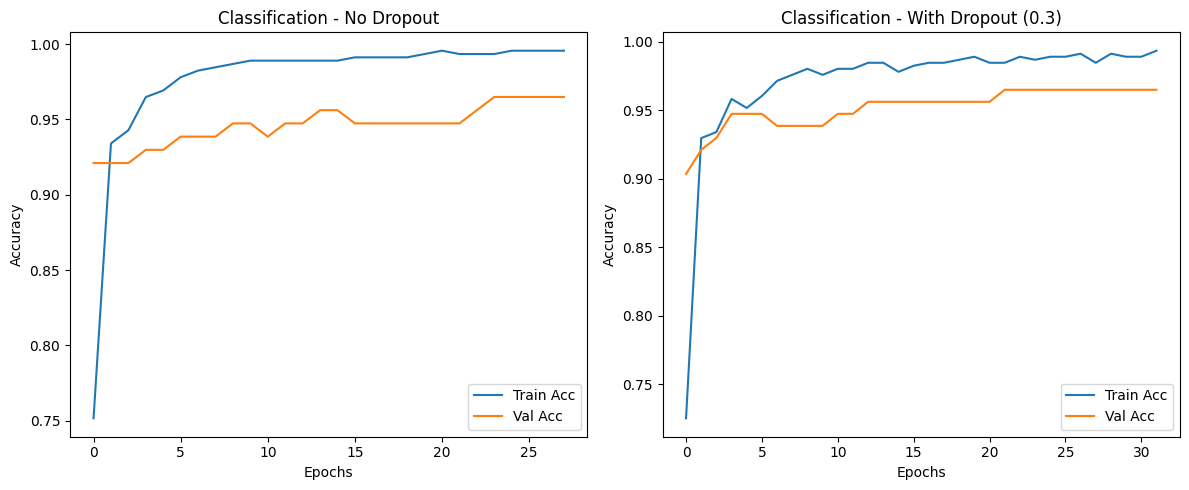

In [13]:
plt.figure(figsize=(12,5))

# Without dropout
plt.subplot(1,2,1)
plt.plot(history_clf_no_drop.history['accuracy'], label='Train Acc')
plt.plot(history_clf_no_drop.history['val_accuracy'], label='Val Acc')
plt.title('Classification - No Dropout')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# With dropout
plt.subplot(1,2,2)
plt.plot(history_clf_drop.history['accuracy'], label='Train Acc')
plt.plot(history_clf_drop.history['val_accuracy'], label='Val Acc')
plt.title('Classification - With Dropout (0.3)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()